## Imports

In [1]:
import sys
import os

# Add notebooks dir to path so tools and utils are importable
notebook_dir = os.getcwd()
sys.path.insert(0, notebook_dir)

from typing import Any, Annotated, List, Literal
from operator import add
import uuid
import json
import re

from openai import OpenAI
from pydantic import BaseModel, Field, field_validator
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

from tools.tools import (

    get_current_date, calculate_date_window,
    check_machine_exists, list_available_machines,
    get_formatted_cm_context,
    get_intervention_detail,
    summarize_intervention,
    build_known_case_template,
    save_known_case_template,
    get_known_case_templates,
    list_intervention_ids_by_date
)

from utils.prompt_management import prompt_template_config


GENERATION_MODEL = "gpt-4o-mini"

## States

In [2]:
class Reference(BaseModel):
    source_id: str

class TemplateReview(BaseModel):
    is_valid: bool = Field(description="Whether the template is valid and reliable")
    issues: List[str] = Field(default_factory=list, description="List of issues found")
    recommendations: List[str] = Field(default_factory=list, description="Recommendations for improvement")

class AgentState(BaseModel):
    messages: Annotated[List[Any], add] = Field(default_factory=list)
    answer: str = ""
    final_answer: bool = False
    template_content: str = ""
    template_review: TemplateReview = Field(default_factory=lambda: TemplateReview(is_valid=True))

class FinalSummarizerResponse(BaseModel):
    answer: str = Field(description="Final answer or follow-up question to the user.")

## Tools

In [ ]:
ALL_TOOLS = [
    get_current_date,
    calculate_date_window,
    check_machine_exists, 
    list_available_machines,
    get_formatted_cm_context,
    get_intervention_detail,
    summarize_intervention,
    build_known_case_template,
    save_known_case_template,
    get_known_case_templates,
    list_intervention_ids_by_date
]

print(f"Defined {len(ALL_TOOLS)} tools: {[t.name for t in ALL_TOOLS]}")

_llm = ChatOpenAI(model=GENERATION_MODEL)
_llm_with_tools = _llm.bind_tools(ALL_TOOLS + [FinalSummarizerResponse], tool_choice="auto", parallel_tool_calls=True)

Defined 11 tools: ['get_current_date', 'calculate_date_window', 'check_machine_exists', 'list_available_machines', 'get_formatted_cm_context', 'get_intervention_detail', 'summarize_intervention', 'build_known_case_template', 'save_known_case_template', 'get_known_case_templates', 'list_intervention_ids_by_date']


## Agent Node

## Validation & Review Node

In [4]:
def validate_template(template_content: str) -> TemplateReview:
    """Review known case template for reliability and structure."""
    issues = []
    recommendations = []
    
    # Check for required sections
    required_sections = ["Symptom Name", "Root Causes", "Affected Machines"]
    for section in required_sections:
        if section not in template_content:
            issues.append(f"Missing required section: '{section}'")
    
    # Check for minimum content in root causes
    if "Root Causes:" in template_content:
        root_causes_section = template_content.split("Root Causes:")[1]
        # Count numbered root causes
        root_cause_count = len([line for line in root_causes_section.split('\n') if line.strip() and line.strip()[0].isdigit()])
        if root_cause_count < 1:
            issues.append("At least one root cause must be documented")
        elif root_cause_count == 1:
            recommendations.append("Consider collecting more interventions to document multiple root causes for better coverage")
    
    # Check for representative intervention IDs
    if "Representative Intervention IDs:" not in template_content:
        issues.append("Missing representative intervention IDs for traceability")
    else:
        # Verify IDs are present
        ids_section = template_content.split("Representative Intervention IDs:")[1]
        if not any(id_marker in ids_section for id_marker in ["INT-"]):
            issues.append("Representative intervention IDs section contains no valid INT- IDs")
    
    # Check for affected machines
    if "Affected Machines:" in template_content:
        machines_section = template_content.split("Affected Machines:")[1].split("\n")[0]
        if not machines_section.strip() or machines_section.strip() == "":
            issues.append("Affected Machines field is empty")
    
    # Check for minimum length to ensure content is substantive
    if len(template_content) < 200:
        issues.append("Template content is too brief; ensure all sections are properly documented")
    
    # Recommendations for structure
    if "**" not in template_content:
        recommendations.append("Consider using bold formatting for section headers for clarity")
    
    is_valid = len(issues) == 0
    return TemplateReview(is_valid=is_valid, issues=issues, recommendations=recommendations)


def template_review_node(state: AgentState) -> dict:
    """Review the generated template and persist if valid."""
    if not state.template_content:
        return state
    
    review = validate_template(state.template_content)
    state.template_review = review
    
    if not review.is_valid:
        # If validation fails, ask agent to fix it
        issues_text = "\n".join([f"- {issue}" for issue in review.issues])
        feedback_msg = f"""
The generated template has validation issues that need to be addressed before sending to the user:

{issues_text}

Please review the template and address these issues. You may need to:
1. Request more intervention summaries from the operator
2. Rebuild the template with more complete information
3. Fill in missing sections with data from the collected interventions

After fixing these issues, I'll validate the template again.
        """
        return {
            "messages": [ToolMessage(content=feedback_msg, tool_call_id="review", name="template_review")],
            "template_review": review
        }
    
    # If valid, parse template and save to database
    try:
        # Extract fields from template content for storage
        symptom_name = extract_field(state.template_content, "Symptom Name:")
        description = extract_field(state.template_content, "Description:")
        affected_machines = extract_field(state.template_content, "Affected Machines:")
        affected_families = extract_field(state.template_content, "Affected Machine Families:")
        representative_ids = extract_field(state.template_content, "Representative Intervention IDs:")
        
        # Parse root causes into structured format
        root_causes = parse_root_causes(state.template_content)
        
        # Save to database
        save_result = save_known_case_template(
            symptom_name=symptom_name,
            description=description,
            root_causes_json=json.dumps(root_causes),
            affected_machines=affected_machines,
            affected_machine_families=affected_families,
            representative_intervention_ids=representative_ids,
            created_by_agent="summarizer_agent",
            validation_status="valid",
            validation_issues_json=json.dumps([])
        ).invoke({})
        
        # Build final answer with save result
        final_answer = state.answer
        if save_result.get("status") == "success":
            template_id = save_result.get("template_id", "")
            final_answer += f"\n\n✓ **Template saved successfully!**\n"
            final_answer += f"- Template ID: `{template_id}`\n"
            final_answer += f"- Created by: {save_result.get('created_at', 'N/A')}\n"
            final_answer += f"- Machines: {', '.join(save_result.get('affected_machines', []))}\n"
            final_answer += f"- Coverage: {len(save_result.get('representative_intervention_ids', []))} interventions\n"
        
        if review.recommendations:
            recommendations_text = "\n".join([f"- {rec}" for rec in review.recommendations])
            final_answer += f"\n\n**Suggestions for improvement:**\n{recommendations_text}"
    
        return {
            "answer": final_answer,
            "template_review": review
        }
    
    except Exception as e:
        error_msg = f"Error saving template: {str(e)}"
        return {
            "answer": state.answer + f"\n\n⚠️ {error_msg}",
            "template_review": review
        }


def extract_field(content: str, field_marker: str) -> str:
    """Extract field value from template content."""
    if field_marker not in content:
        return ""
    
    start = content.find(field_marker) + len(field_marker)
    # Find next section or end of content
    next_section = content.find("\n**", start)
    if next_section == -1:
        end = len(content)
    else:
        end = next_section
    
    return content[start:end].strip()


def parse_root_causes(content: str) -> list[dict]:
    """Parse root causes section into structured format."""
    root_causes = []
    
    if "Root Causes:" not in content:
        return root_causes
    
    section = content.split("Root Causes:")[1]
    if "Affected Machines:" in section:
        section = section.split("Affected Machines:")[0]
    
    # Parse numbered root causes
    import re
    pattern = r'^\d+\.\s+\*\*([^*]+)\*\*'
    for line in section.split('\n'):
        match = re.match(pattern, line)
        if match:
            root_cause_name = match.group(1)
            root_causes.append({
                "root_cause": root_cause_name,
                "actions": []
            })
    
    return root_causes

In [5]:
def agent_node(state: AgentState) -> dict:
    SYSTEM_PROMPT = """
    You are a maintenance case analyst for past interventions. Help operators build known case templates by:
    1. Collecting machine, date range, and symptom
    2. Listing available interventions
    3. Waiting for operator to select which interventions to analyze
    4. Summarizing ONLY the selected interventions
    5. Building a template from those summaries

    ## Critical Workflow

    **STEP 1: List** — Get all INT-IDs for the machine/period
    - Use: list_intervention_ids_by_date()
    - Report count and list of INT-IDs by date order.
    - Wait for operator to provide a selection ONLY if count > 20. Otherwise, continue

    **STEP 2: Summarize** — Only after operator selects, summarize each INT
    - Use: summarize_intervention() for EACH selected INT-ID (can run in parallel)
    - Each summary is returned as "[INT: ID] summary text"
    - Collect ALL summaries and display them to operator with their [INT: ...] markers INTACT
    - Ask: "Anything else? I can also build a template of known cases for select IDs.

    **STEP 3: Build** — Only after operator confirms, build the template
    - Use: build_known_case_template() with ALL collected summaries joined together
    - Pass summaries EXACTLY AS RETURNED (with [INT: ...] markers) - do NOT reformat
    - Make sure you have included all IDs (directly and indirectly) informed by user
    - Present final template

    ## Summary Handling - IMPORTANT
    - When summarize_intervention() returns a summary, it includes "[INT: XXX-YYYY]" prefix
    - PRESERVE these markers - do not remove or reformat them
    - When showing summaries to operator, keep the [INT: ...] format visible
    - When passing to build_known_case_template(), concatenate all summaries as-is with newlines

    ## Required Information
    Collect once: machine_id, start_date, end_date, symptom (in a single request if missing).

    ## Confirmation Strategy
    - Do NOT reconfirm provided inputs.
    - Ask for selection: "Which INT-IDs to summarize?" (comma-separated or list)
    - Ask for confirmation: "Should I proceed to build the template from these summaries?" before calling build_known_case_template().
    - Never skip the summarize step or jump directly to build.

    ## Date Handling
    - Use get_current_date() and calculate_date_window() for relative dates.
    - Always work with ISO format (YYYY-MM-DD).
    """
    
    response = _llm_with_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT), *state.messages]
    )

    final_call = next(
        (tc for tc in response.tool_calls if tc["name"] == "FinalSummarizerResponse"),
        None
    )
    if final_call:
        parsed = FinalSummarizerResponse(**final_call["args"])
        return {
            "messages": [response],
            "answer": parsed.answer,
            "final_answer": True,
        }

    # LLM called real tools — let tools node run
    if response.tool_calls:
        return {"messages": [response], "final_answer": False}

    # Plain text response (no tool calls) — treat content as answer
    return {
        "messages": [response],
        "answer": response.content,
        "final_answer": True,
    }

In [ ]:
def route_after_agent(state: AgentState) -> str:
    """Route from agent: to tools, template review, or end."""
    if state.final_answer:
        # If we have template content, send to review; otherwise end
        if state.template_content:
            return "template_review"
        return END
    
    last_msg = state.messages[-1]
    if isinstance(last_msg, AIMessage) and getattr(last_msg, 'tool_calls', None):
        return "tools"
    return END

In [ ]:
tool_node = ToolNode(ALL_TOOLS)

workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", handle_tool_calls)
workflow.add_node("template_review", template_review_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", route_after_agent, {"tools": "tools", "template_review": "template_review", END: END})
workflow.add_edge("tools", "agent")
workflow.add_edge("template_review", END)

graph = workflow.compile(checkpointer=MemorySaver())

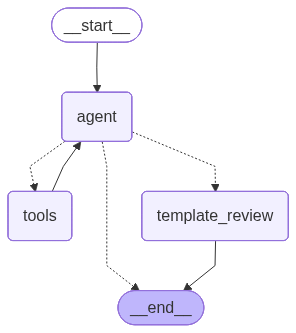

In [8]:
from utils.utils import display_graph
display_graph(graph)

In [9]:
def multi_turn_summarizer_chat():
    print("✓ Interactive Summarizer Agent — type 'exit' to quit.\n")

    thread_id = f"rca-{uuid.uuid4().hex[:12]}"
    config = {"configurable": {"thread_id": thread_id}}

    while True:
        user_input = input("You: ").strip()
        if user_input.lower() == "exit":
            print("\nSession ended.")
            break
        if not user_input:
            continue

        result = graph.invoke(
            {"messages": [HumanMessage(content=user_input)]},
            config=config
        )

        print(f"\nAgent:\n{result['answer']}\n")


multi_turn_summarizer_chat()

✓ Interactive Summarizer Agent — type 'exit' to quit.


Agent:
Here are the summaries of the interventions related to the oil temperature problem on machine HX-200 in the specified date range:

1. **[INT: INT-2025-0366]** On HX-200’s hydraulic subsystem, a WARNING for high oil temperature (E-002) was addressed as corrective maintenance. The root cause was identified as fan failure, the issue was corrected by the technician, and a functional test was completed successfully with supervision by Moreau, L.

2. **[INT: INT-2025-0410]** On the HX-200 hydraulic press, a corrective maintenance (CM) intervention was performed for a WARNING high oil temperature fault (E-002) during 2025-04-21. The root cause was identified as a low oil level, which was corrected, and a functional test was successfully completed.

3. **[INT: INT-2025-0309]** For hydraulic subsystem fault code E-002 (high oil temperature) on the HX-200 hydraulic press, corrective maintenance was performed as a WARNING-level CM int